# Práctica 1 - Germán Cousillas Martínez

## Apartado 1

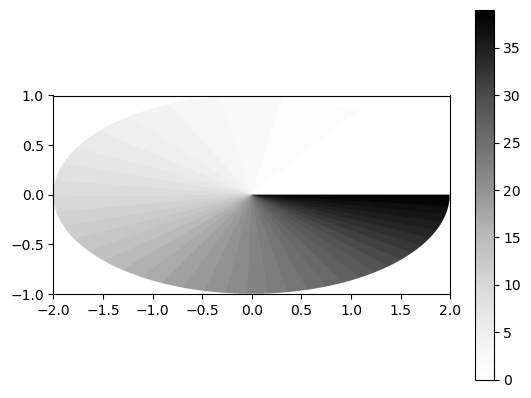

In [2]:
import numpy as np
import matplotlib.pyplot as plt

p0 = 1

# En primer lugar, construimos el plano XY especificado

tx = np.linspace(-2,2,1000)
ty = np.linspace(-1,1,1000)

X, Y = np.meshgrid(tx, ty)

# Ahora construimos la función de densidad

def rho(x, y, z):
    if (np.abs(z) < 1) and (x**2+4*y**2<=4):
        phi = np.arctan2(y/(1/2),x)
        if phi < 0: # arctan2 da los ángulos entre -pi y pi. Para pasar a la representación 0,2pi tengo que sumar 2pi a los ángulos negativos
            phi+= 2*np.pi
        return p0*phi**2*(1-z**2)
    return 0

rho = np.vectorize(rho)

V = rho(X, Y, 0)
plt.imshow(V, origin="lower", extent=[-2,2,-1,1], cmap="Greys")
plt.colorbar()
plt.show()

## Apartado 2

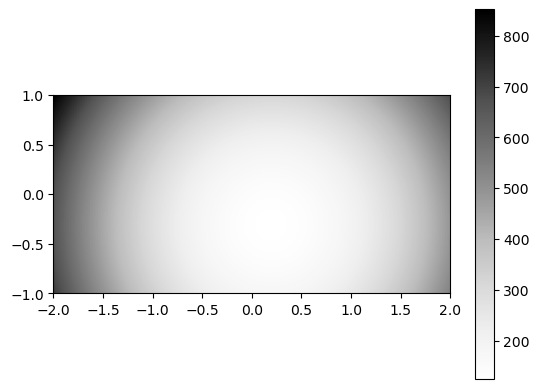

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxw

N=20 # Empleamos cuadratura Gaussiana porque el integrando es suficientemente suave salvo en la frontera entre phi=0 y phi=2pi

x, w = gaussxw(N)

a=0
b=2
r_roots = 1/2*((b-a)*x+(b+a))
w_r = 1/2*(b-a)*w

a=0
b=2*np.pi
phi_roots = 1/2*((b-a)*x+(b+a))
w_phi = 1/2*(b-a)*w

z_roots = x
w_z = w


def p(r, phi, z):
    return p0*phi**2*(1-z**2)

def Iz(x0, y0):
    Iz = 0
    f = lambda r, phi, z: p(r, phi, z)*((r*np.cos(phi)-x0)**2+(r*np.sin(phi)/2-y0)**2)*r
    
    for i in range(len(r_roots)):
        for j in range(len(phi_roots)):
            for k in range(len(z_roots)):
                Iz+=w_r[i]*w_phi[j]*w_z[k]*f(r_roots[i], phi_roots[j], z_roots[k])
    return Iz/2

tx = np.linspace(-2,2,150)
ty = np.linspace(-1,1,150)

X, Y = np.meshgrid(tx, ty)

plt.imshow(Iz(X, Y), origin="lower", extent=[-2,2,-1,1], cmap="Greys")
plt.colorbar()
plt.show()

## Apartado 3

In [27]:
import numpy as np

# Siempre vamos a integrar en el mismo recinto, de modo que no es preciso que toquemos nada de los límites de integración del apartado anterior

fxx = lambda r, phi, z: p(r, phi, z)*(1/4*r**2*np.sin(phi)**2+z**2)
fyy = lambda r, phi, z: p(r, phi, z)*(r**2*np.cos(phi)**2+z**2)
fzz = lambda r, phi, z: p(r, phi, z)*(r**2*np.cos(phi)**2+1/4*r**2*np.sin(phi)**2)
fxy = lambda r, phi, z: -p(r, phi, z)*r*np.cos(phi)*r*np.sin(phi)/2
fxz = lambda r, phi, z: -p(r, phi, z)*r*np.cos(phi)*z
fyz = lambda r, phi, z: -p(r, phi, z)*r*np.sin(phi)*z


Ixx = 0
Iyy = 0
Izz = 0
Ixy = 0
Ixz = 0
Iyz = 0

for i in range(len(r_roots)):
    a = r_roots[i]
    for j in range(len(phi_roots)):
        b = phi_roots[j]
        for k in range(len(z_roots)):
            c = z_roots[k]
            factor = w_r[i]*w_phi[j]*w_z[k]
            Ixx += factor*fxx(a, b, c)
            Iyy += factor*fyy(a, b, c)
            Izz += factor*fzz(a, b, c)
            Ixy += factor*fxy(a, b, c)
            Ixz += factor*fxz(a, b, c)
            Iyz += factor*fyz(a, b, c)

I = np.array([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])/2
print(I)

[[ 3.97248660e+01  8.77298169e+00 -2.26546241e-14]
 [ 8.77298169e+00  9.83377942e+01  7.20539910e-14]
 [-2.26546241e-14  7.20539910e-14  9.39648445e+01]]


## Apartado 4

In [31]:
def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x
    
def sust_adelant(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N):
        x[i] = B[i]
        for n in range(i):
            x[i]-=A[i,n]*x[n]
        x[i] /= d[i]
    return x

In [32]:
import numpy as np

def LUP(A): # Programa que factoriza A en matrices triangular inf y sup
    U = A.copy()
    L = np.zeros_like(U)
    
    
    N = len(A)
    P = np.eye(N)
    
    for i in range(N):
        L[i:,i] = U[i:,i]
        
        subcol = U[i:,i]
        pivot = np.max(subcol)
        ind = np.where(subcol==pivot)[0][0]+i
        
        U[i,:], U[ind, :] = U[ind, :].copy(), U[i, :].copy()
        L[i,:], L[ind, :] = L[ind, :].copy(), L[i, :].copy()
        P[i,:], P[ind, :] = P[ind, :].copy(), P[i, :].copy()
        
        U[i,:] /= pivot

        for k in range(i+1, N):
            mult = U[k,i]
            U[k,:] -= mult*U[i,:]
    return L, U, P

def solveLU(L, U, PV):
    # Se trata ahora de resolver dos sistemas de ecuaciones
    # 1. Ly == PV (sust hacia delante)
    # 2. Ux = y (sust hacia atrás)
    
    y = sust_adelant(L, PV)
    x = sust_atras(U, y)
    return x

A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
B=np.array([-4,3,9,7],float)

L, U, P = LUP(A)

In [33]:
import numpy as np

B = np.array([2,2,2], float) # L

L, U, P = LUP(I)
w = solveLU(L, U, np.dot(P, B))
print(w)

[0.04677636 0.01616501 0.02128456]


## Apartado 5 (Extra)

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Miminimizo cálculos haciendo de antemano la integral de la densidad en el recinto de integración

M=0

for i in range(len(r_roots)):
    a = r_roots[i]
    for j in range(len(phi_roots)):
        b = phi_roots[j]
        for k in range(len(z_roots)):
            c = z_roots[k]
            M+= w_r[i]*w_phi[j]*w_z[k]*p(a, b, c)


fx = lambda r, phi, z: p(r, phi, z)*r*np.cos(phi)/2 # Factor 2 por Jacobiano
fy = lambda r, phi, z: p(r, phi, z)*r*np.sin(phi)/4 # Factor 2 por Jacobiano y otro por "y"

x_cm = 0
y_cm = 0

for i in range(len(r_roots)):
    a = r_roots[i]
    for j in range(len(phi_roots)):
        b = phi_roots[j]
        for k in range(len(z_roots)):
            c = z_roots[k]
            x_cm+= w_r[i]*w_phi[j]*w_z[k]*fx(a, b, c)
            y_cm+= w_r[i]*w_phi[j]*w_z[k]*fy(a, b, c)
            
x_cm /= M
y_cm /= M

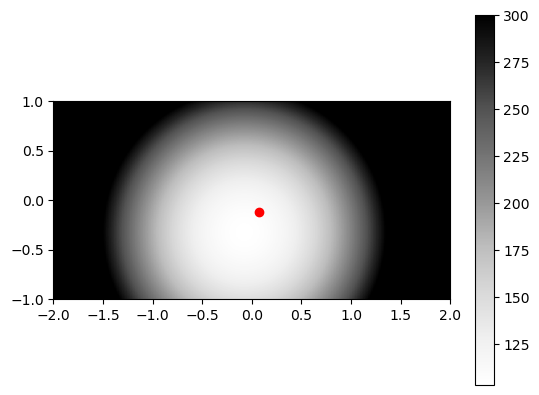

In [46]:
tx = np.linspace(-2,2,150)
ty = np.linspace(-1,1,150)

X, Y = np.meshgrid(tx, ty)

plt.imshow(Iz(X, Y), origin="lower", extent=[-2,2,-1,1], cmap="Greys", vmax=300)
plt.colorbar()
plt.plot(x_cm, y_cm, "ro")
plt.show()

Notamos que el momento de inercia del sólido es mínimo cuando se toma en torno al centro de masas. Esto es prcisamente lo que establece el teorema de Steiner.